Welcome!

This notebook contains Machine Learning Pet Project on Breast Cancer Wisconsin Dataset. Enjoy!

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

## Breast Cancer Wisconsin Dataset

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image.

**30 Features (mean, standard error, and worst for each):**

1. radius - mean of distances from center to points on the perimeter
2. texture - standard deviation of gray-scale values
3. perimeter
4. area
5. smoothness - local variation in radius lengths
6. compactness - perimeter² / area - 1.0
7. concavity - severity of concave portions of the contour
8. concave points - number of concave portions of the contour
9. symmetry
10. fractal dimension - "coastline approximation" - 1

**Target Variable:**
- 0: Malignant (cancerous)
- 1: Benign (non-cancerous)

## Data Loading

In [40]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [41]:
print(f"Dataset shape: {df.shape}")
print(f"\nFeature names: {data.feature_names}")
print(f"\nTarget names: {data.target_names}")

Dataset shape: (569, 31)

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names: ['malignant' 'benign']


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [43]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Data Cleaning

### Missing Values

In [44]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Total missing values: 0


### Outliers Detection

In [45]:
def detect_outliers_iqr(dataframe, feature):
    Q1 = dataframe[feature].quantile(0.25)
    Q3 = dataframe[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[feature] < lower_bound) | (dataframe[feature] > upper_bound)]
    return len(outliers)

# Check outliers for numerical features
outlier_counts = {}
for col in df.columns[:-1]:  # Exclude target
    outlier_counts[col] = detect_outliers_iqr(df, col)

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
outlier_df[outlier_df['Outlier Count'] > 0].sort_values('Outlier Count', ascending=False).head(10)

,Outlier Count
area error,65
radius error,38
perimeter error,38
worst area,35
smoothness error,30
compactness error,28
fractal dimension error,28
symmetry error,27
mean area,25
worst fractal dimension,24


Note: In medical datasets, outliers often represent important edge cases. We'll keep them for now but may consider robust scaling.

## Exploratory Data Analysis

### Target Distribution

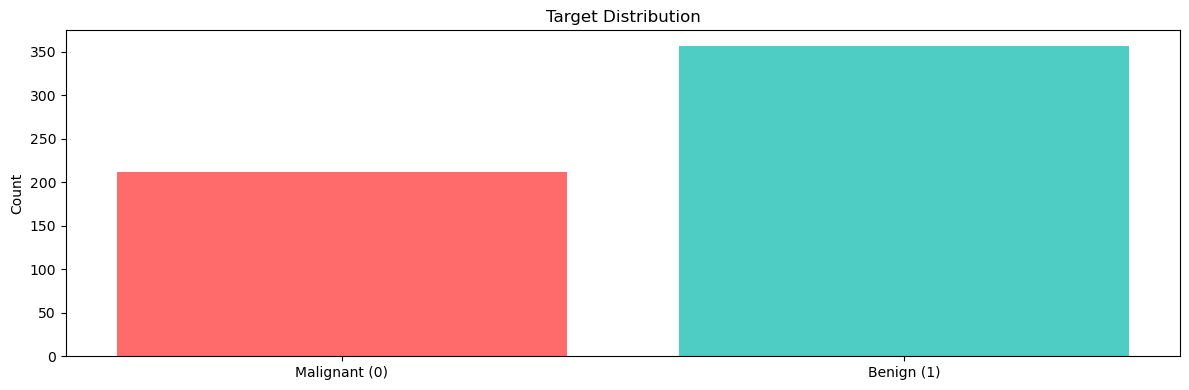

Malignant: 212 (37.3%)
Benign: 357 (62.7%)


In [46]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# Count plot
target_counts = df['target'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
ax.bar(['Malignant (0)', 'Benign (1)'], [target_counts[0], target_counts[1]], color=colors)
ax.set_title('Target Distribution')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Malignant: {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Benign: {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

# Feature Distributions

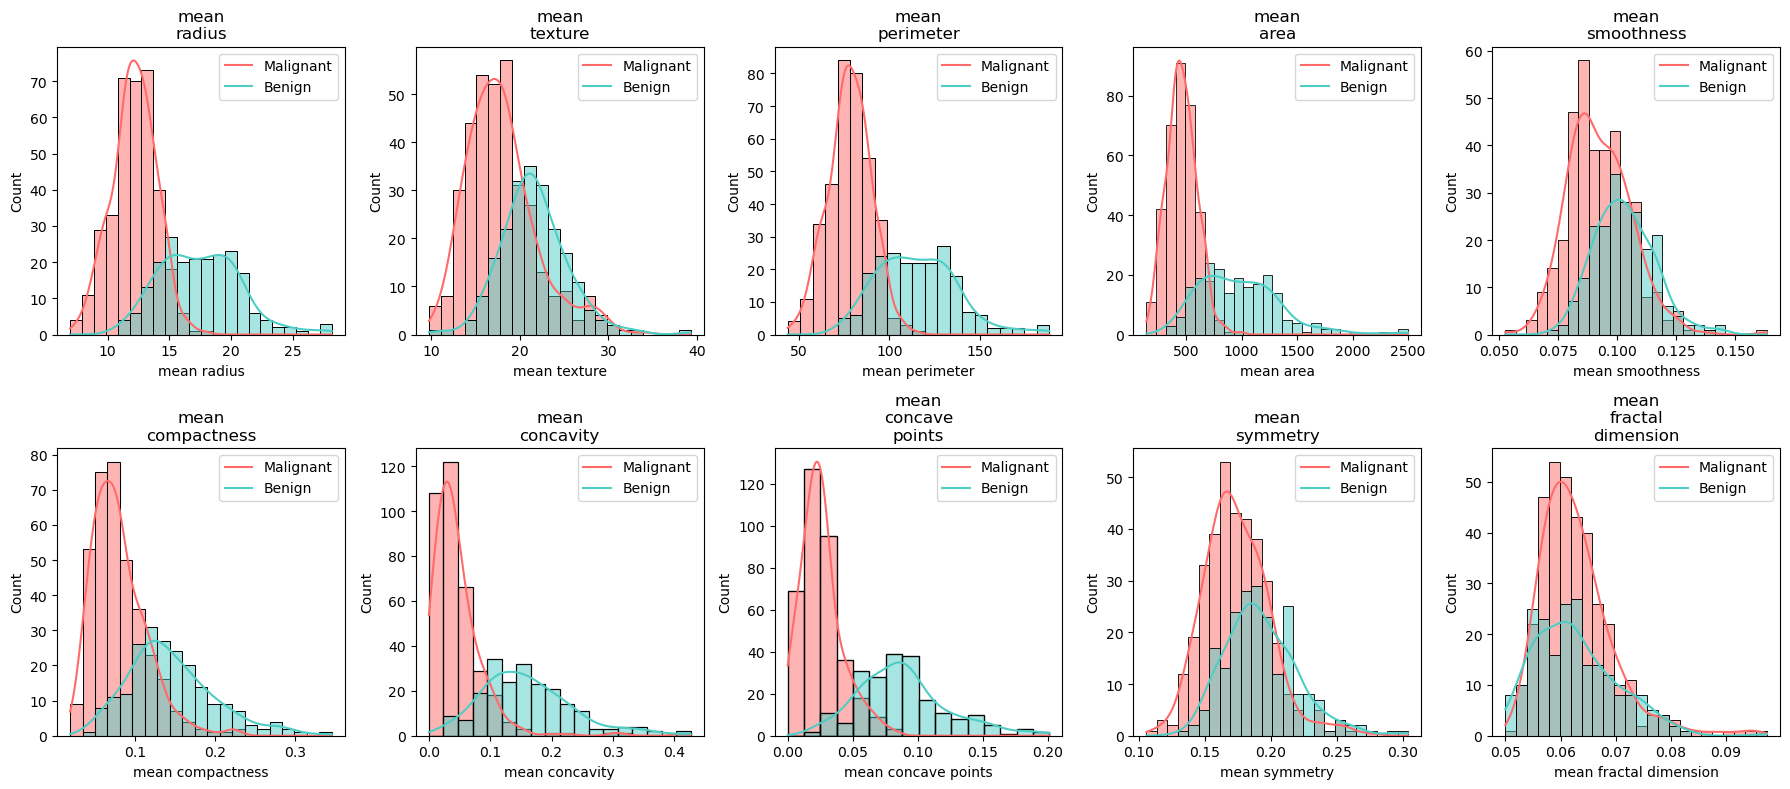

In [47]:
# Select mean features for visualization
mean_features = [col for col in df.columns if 'mean' in col]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, feature in enumerate(mean_features):
    sns.histplot(data=df, x=feature, hue='target', kde=True, ax=axes[idx], palette=[ '#4ecdc4', '#ff6b6b'])
    axes[idx].set_title(feature.replace(' ', '\n'))
    axes[idx].legend(['Malignant', 'Benign'])

plt.tight_layout()
plt.show()

### Box Plots by Target

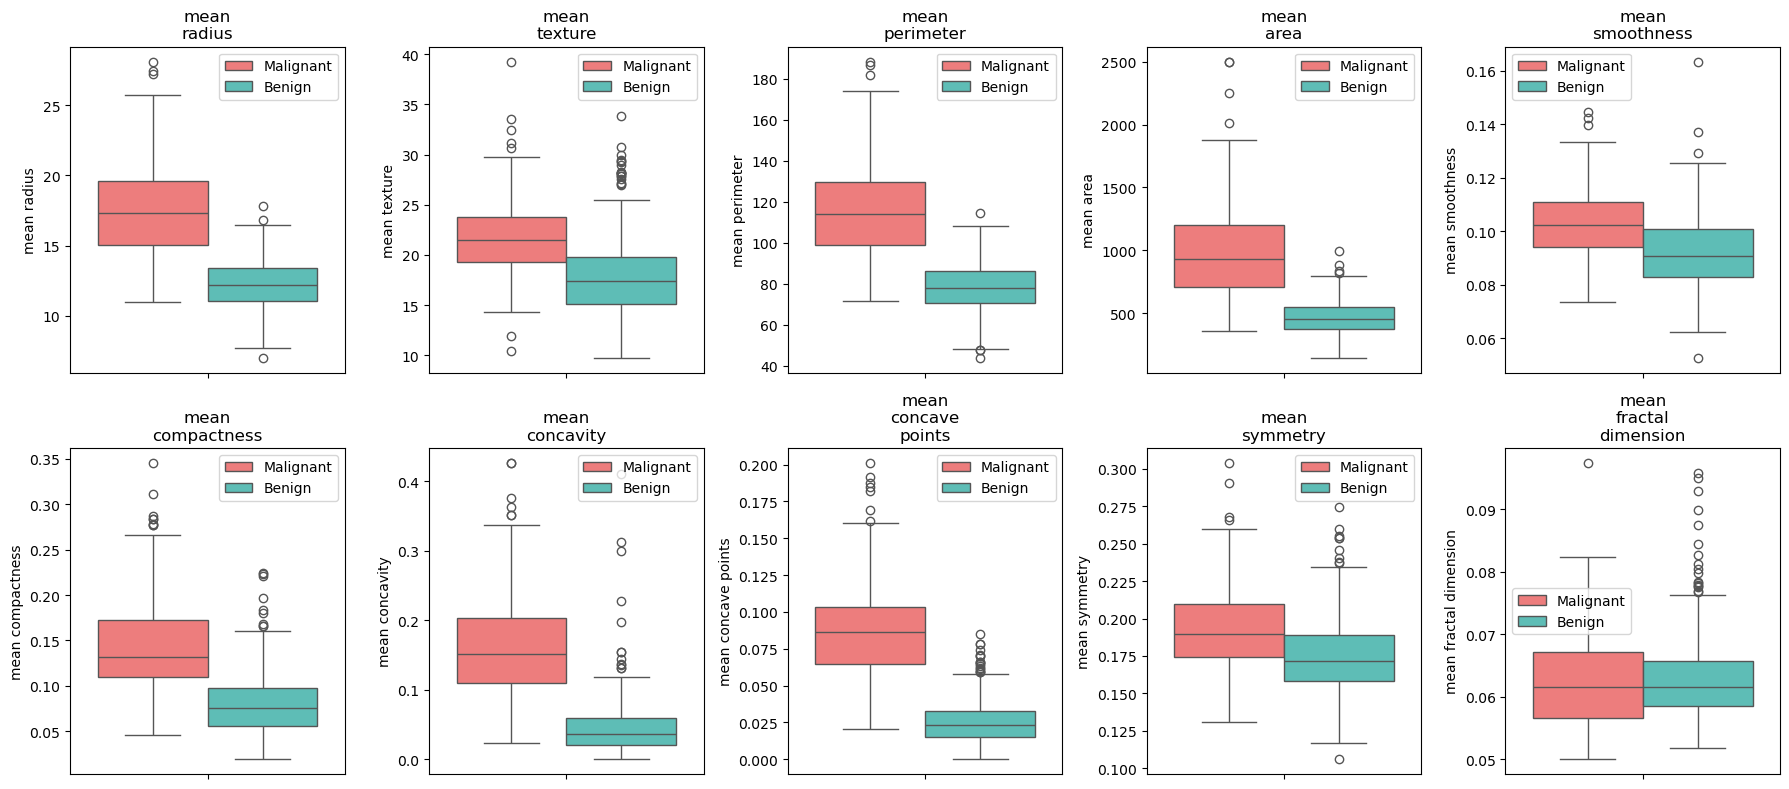

In [48]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, feature in enumerate(mean_features):
    sns.boxplot(data=df, hue='target', y=feature, ax=axes[idx], palette=['#ff6b6b', '#4ecdc4'])
    axes[idx].set_title(feature.replace(' ', '\n'))
    axes[idx].legend(['Malignant', 'Benign'])

plt.tight_layout()
plt.show()

### Correlation Analysis

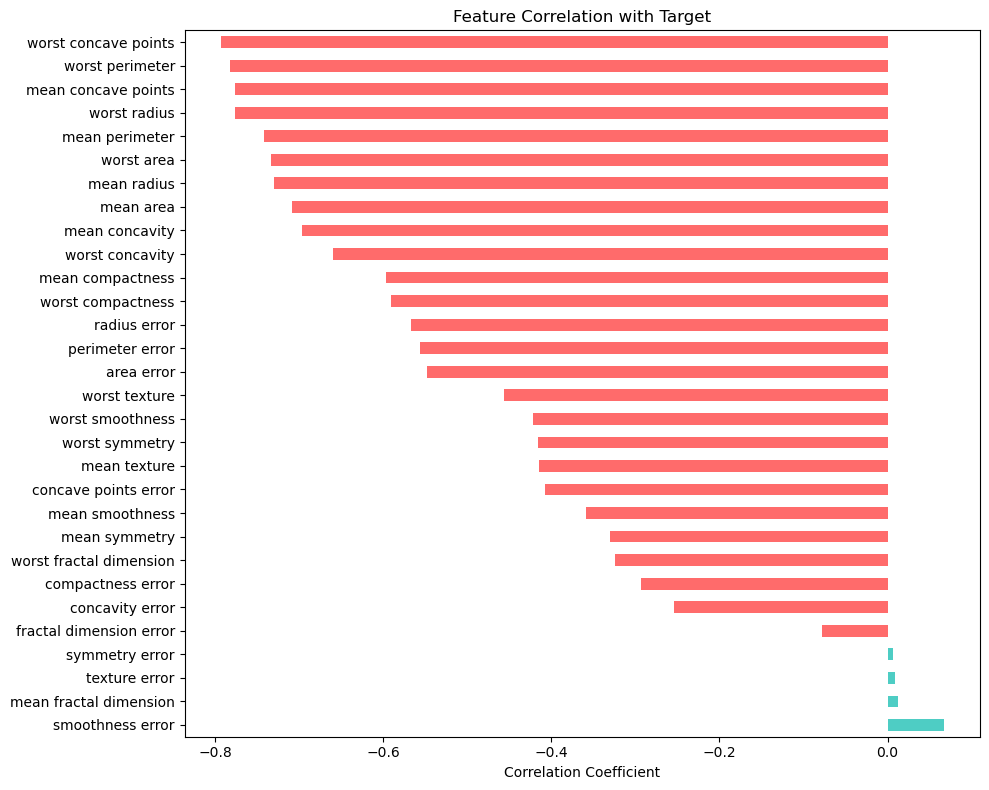

In [49]:
# Correlation with target
correlations = df.corr()['target'].drop('target').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#4ecdc4' if x > 0 else '#ff6b6b' for x in correlations]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Correlation with Target')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

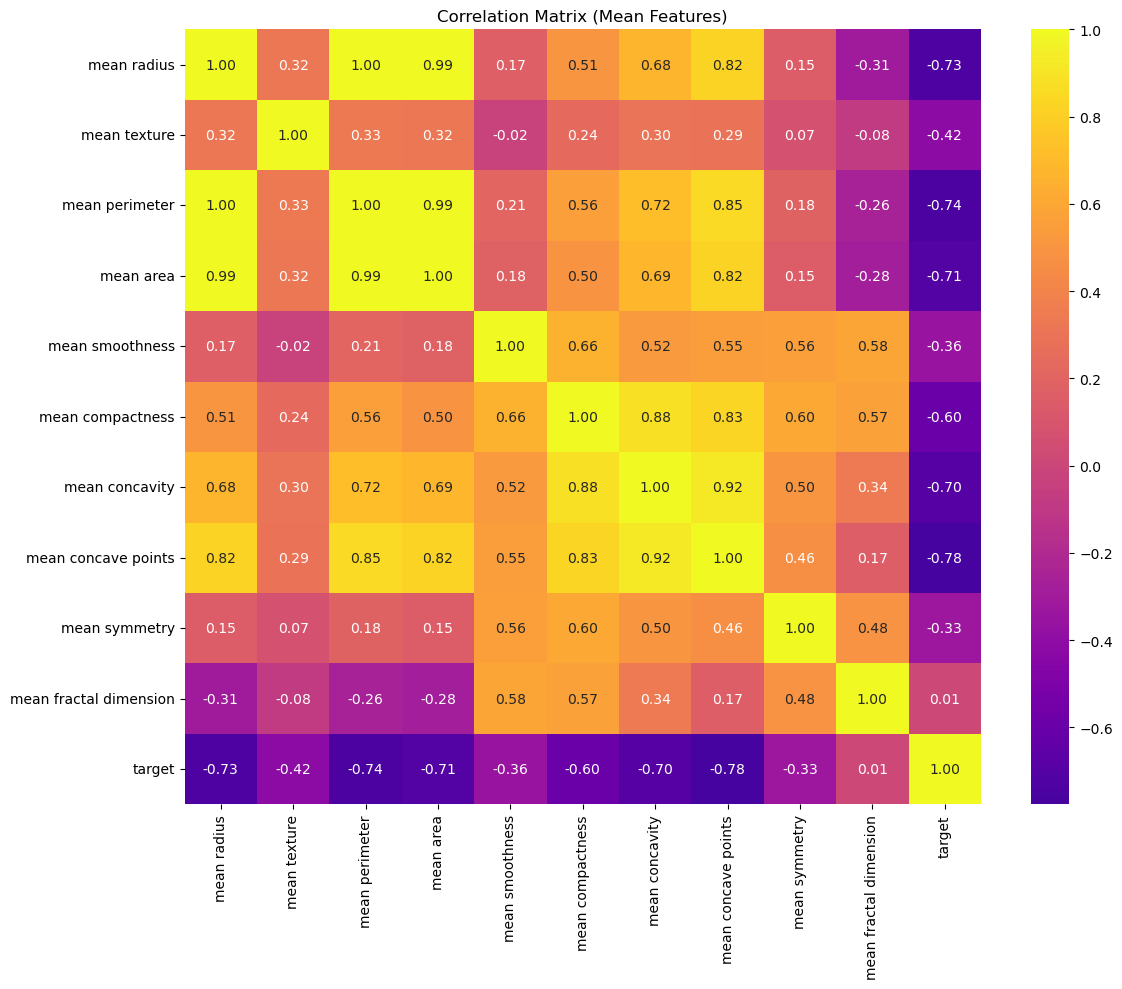

In [50]:
# Full correlation matrix for mean features
mean_cols = mean_features + ['target']
plt.figure(figsize=(12, 10))
sns.heatmap(df[mean_cols].corr(), annot=True, cmap='plasma', center=0, fmt='.2f')
plt.title('Correlation Matrix (Mean Features)')
plt.tight_layout()
plt.show()

### Pairplot of Top Features

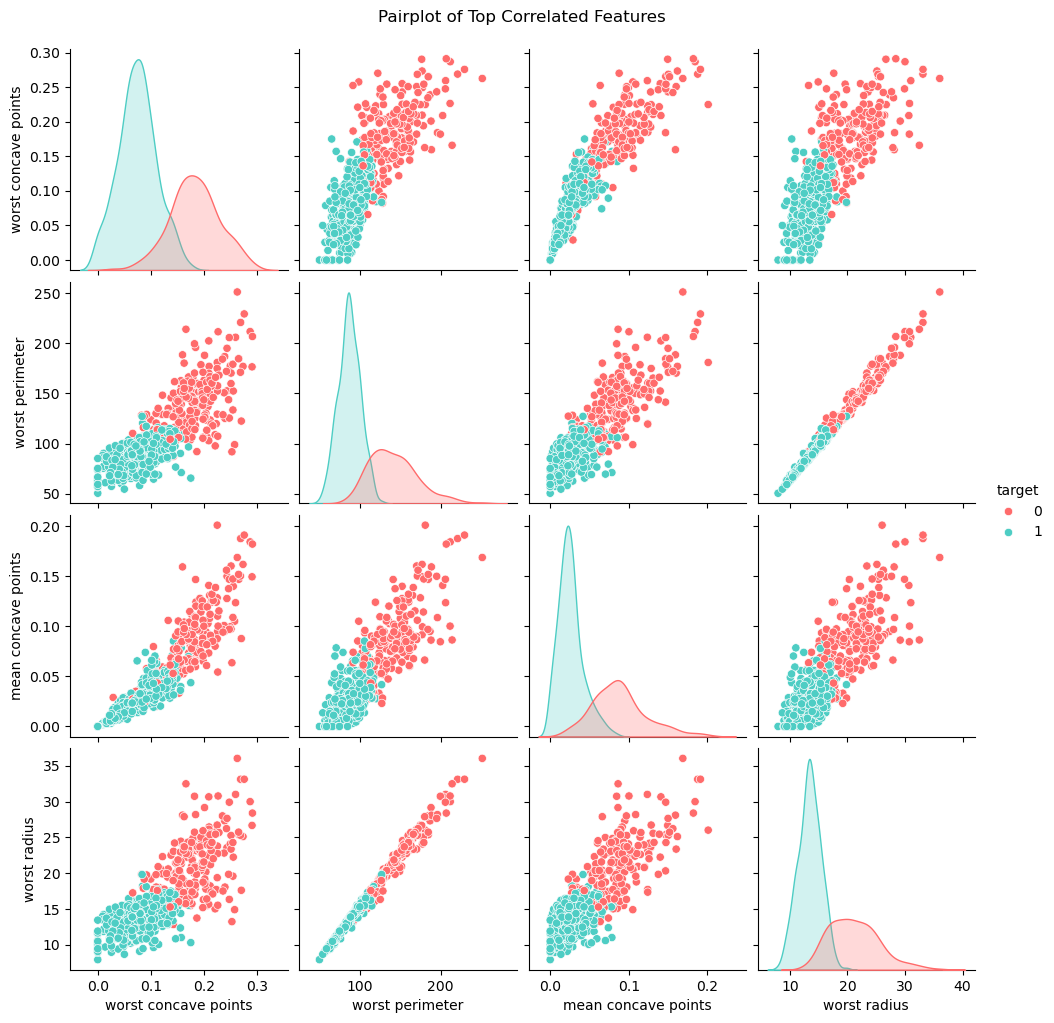

In [51]:
# Select top 4 correlated features
top_features = correlations.abs().sort_values(ascending=False).head(4).index.tolist()
sns.pairplot(df[top_features + ['target']], hue='target', palette=['#ff6b6b', '#4ecdc4'])
plt.suptitle('Pairplot of Top Correlated Features', y=1.02)
plt.show()

## Feature Engineering

### Handling Highly Correlated Features

Some features are highly correlated with each other (e.g., radius, perimeter, area). We can either:
1. Remove redundant features
2. Apply PCA

Let's identify highly correlated feature pairs.

In [12]:
def find_high_correlations(dataframe, threshold=0.9):
    corr_matrix = dataframe.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_pairs = []
    
    for column in upper_tri.columns:
        for index in upper_tri.index:
            if upper_tri.loc[index, column] > threshold:
                high_corr_pairs.append((index, column, upper_tri.loc[index, column]))
    
    return pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])

high_corr = find_high_correlations(df.drop('target', axis=1), threshold=0.9)
print(f"Found {len(high_corr)} highly correlated feature pairs (r > 0.9):")
high_corr.sort_values('Correlation', ascending=False)

Found 21 highly correlated feature pairs (r > 0.9):


,Feature 1,Feature 2,Correlation
0,mean radius,mean perimeter,0.997855
14,worst radius,worst perimeter,0.993708
1,mean radius,mean area,0.987357
2,mean perimeter,mean area,0.986507
18,worst radius,worst area,0.984015
19,worst perimeter,worst area,0.977578
4,radius error,perimeter error,0.972794
12,mean perimeter,worst perimeter,0.970387
7,mean radius,worst radius,0.969539
8,mean perimeter,worst radius,0.969476


## Train-Test Split

In [52]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True)}")

Training set size: 455
Test set size: 114

Training target distribution:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Test target distribution:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## Feature Scaling

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled features sample:")
X_train_scaled.head()

Scaled features sample:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,...,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
432,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,...,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
174,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,...,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
221,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,...,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
289,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,...,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


## Principal Component Analysis (PCA)

Optional: Apply PCA to reduce dimensionality and handle multicollinearity.

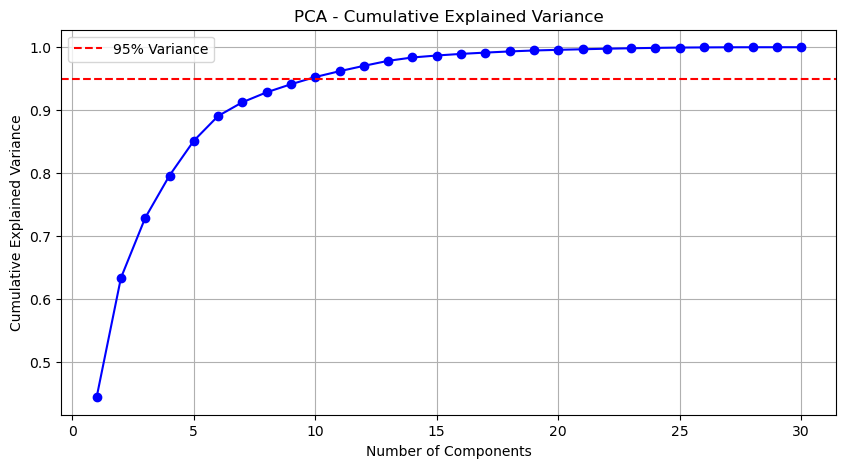

Number of components for 95% variance: 10


In [54]:
from sklearn.decomposition import PCA

# Fit PCA to see explained variance
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components for 95% variance: {n_components_95}")

In [55]:
# Apply PCA with selected components
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original shape: {X_train_scaled.shape}")
print(f"PCA shape: {X_train_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

Original shape: (455, 30)
PCA shape: (455, 10)
Explained variance ratio: 0.9527


## Model Training

We'll use the scaled data (without PCA) for better interpretability, but PCA data can be used alternatively.

### Baseline Model - Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train baseline model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)

print("Baseline Model: Logistic Regression")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Malignant', 'Benign'])}")

Baseline Model: Logistic Regression
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



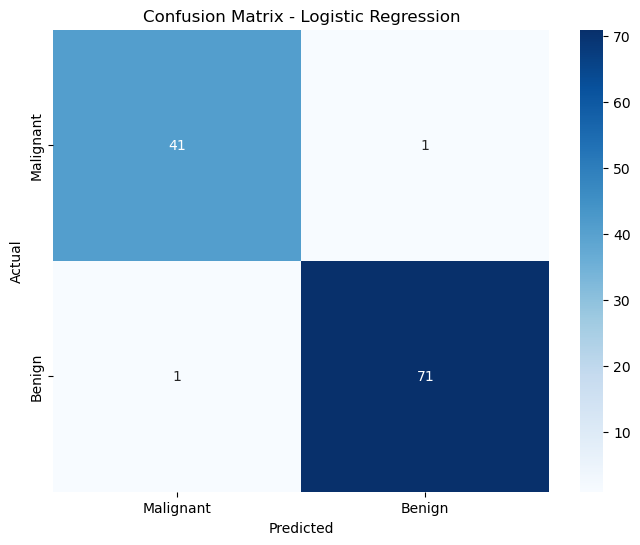

In [57]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant', 'Benign'], 
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Multi-Model Comparison

Custom Classifier class to train and compare multiple models.

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time


class Classifier:
    def __init__(self, models=None, param_grids=None, use_gridsearch=False):
        if models is None:
            self.models = {
                'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
                'DecisionTree': DecisionTreeClassifier(random_state=42),
                'RandomForest': RandomForestClassifier(random_state=42),
                'GradientBoosting': GradientBoostingClassifier(random_state=42),
                'SVM': SVC(random_state=42, probability=True),
                'KNeighbors': KNeighborsClassifier(),
                'NaiveBayes': GaussianNB(),
                'AdaBoost': AdaBoostClassifier(random_state=42, algorithm='SAMME')
            }
        else:
            self.models = models
        
        self.default_param_grids = {
            'LogisticRegression': {'C': [0.1, 1.0, 10.0], 'penalty': ['l2']},
            'DecisionTree': {'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]},
            'RandomForest': {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]},
            'GradientBoosting': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.2]},
            'SVM': {'C': [0.1, 1.0, 10.0], 'kernel': ['rbf', 'linear']},
            'KNeighbors': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
            'NaiveBayes': {},
            'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 1.0]}
        }
        
        self.param_grids = param_grids if param_grids else self.default_param_grids
        self.use_gridsearch = use_gridsearch
        self.fitted_models = {}
        self.best_model_params = {}
    
    def run(self, X_train, y_train, X_test, y_test):
        results = []
        
        for name, model in self.models.items():
            print(f"\nFitting {name}...")
            start_time = time.time()
            
            if self.use_gridsearch and name in self.param_grids and self.param_grids[name]:
                grid_search = GridSearchCV(
                    model, 
                    self.param_grids[name], 
                    cv=5, 
                    scoring='accuracy',
                    n_jobs=-1
                )
                grid_search.fit(X_train, y_train)
                best_model = grid_search.best_estimator_
                self.best_model_params[name] = grid_search.best_params_
            else:
                best_model = model
                best_model.fit(X_train, y_train)
            
            elapsed_time = time.time() - start_time
            print(f"{name} trained in {elapsed_time:.2f}s")
            
            self.fitted_models[name] = best_model
            
            # Training metrics
            y_train_pred = best_model.predict(X_train)
            train_accuracy = accuracy_score(y_train, y_train_pred)
            train_f1 = f1_score(y_train, y_train_pred)
            
            # Test metrics
            y_test_pred = best_model.predict(X_test)
            test_accuracy = accuracy_score(y_test, y_test_pred)
            test_precision = precision_score(y_test, y_test_pred)
            test_recall = recall_score(y_test, y_test_pred)
            test_f1 = f1_score(y_test, y_test_pred)
            
            # ROC AUC
            if hasattr(best_model, 'predict_proba'):
                y_proba = best_model.predict_proba(X_test)[:, 1]
                test_roc_auc = roc_auc_score(y_test, y_proba)
            else:
                test_roc_auc = np.nan
            
            results.append({
                'Model': name,
                'Accuracy_Train': train_accuracy,
                'Accuracy_Test': test_accuracy,
                'Precision_Test': test_precision,
                'Recall_Test': test_recall,
                'F1_Train': train_f1,
                'F1_Test': test_f1,
                'ROC_AUC_Test': test_roc_auc,
                'Time_s': elapsed_time
            })
        
        results_df = pd.DataFrame(results)
        results_df.set_index('Model', inplace=True)
        return results_df

### Training with Default Parameters

In [59]:
classifier_default = Classifier(use_gridsearch=False)
results_default = classifier_default.run(X_train_scaled, y_train, X_test_scaled, y_test)
results_default.sort_values('F1_Test', ascending=False)


Fitting LogisticRegression...
LogisticRegression trained in 0.00s

Fitting DecisionTree...
DecisionTree trained in 0.01s

Fitting RandomForest...
RandomForest trained in 0.19s

Fitting GradientBoosting...
GradientBoosting trained in 0.46s

Fitting SVM...
SVM trained in 0.02s

Fitting KNeighbors...
KNeighbors trained in 0.00s

Fitting NaiveBayes...
NaiveBayes trained in 0.00s

Fitting AdaBoost...
AdaBoost trained in 0.15s


D:\Conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


,Accuracy_Train,Accuracy_Test,Precision_Test,Recall_Test,F1_Train,F1_Test,ROC_AUC_Test,Time_s
Model,,,,,,,,
LogisticRegression,0.989011,0.982456,0.986111,0.986111,0.991274,0.986111,0.995370,0.004390
SVM,0.982418,0.982456,0.986111,0.986111,0.986063,0.986111,0.995040,0.017444
AdaBoost,1.000000,0.956140,0.946667,0.986111,1.000000,0.965986,0.982474,0.151654
GradientBoosting,1.000000,0.956140,0.946667,0.986111,1.000000,0.965986,0.990741,0.455276
KNeighbors,0.973626,0.956140,0.958904,0.972222,0.979167,0.965517,0.978836,0.001163
RandomForest,1.000000,0.956140,0.958904,0.972222,1.000000,0.965517,0.993882,0.188237
NaiveBayes,0.938462,0.929825,0.944444,0.944444,0.951220,0.944444,0.986772,0.001438
DecisionTree,1.000000,0.912281,0.955882,0.902778,1.000000,0.928571,0.915675,0.009708


### Training with GridSearchCV

In [60]:
classifier_grid = Classifier(use_gridsearch=True)
results_grid = classifier_grid.run(X_train_scaled, y_train, X_test_scaled, y_test)
results_grid.sort_values('F1_Test', ascending=False)


Fitting LogisticRegression...
LogisticRegression trained in 5.40s

Fitting DecisionTree...
DecisionTree trained in 0.22s

Fitting RandomForest...
RandomForest trained in 1.99s

Fitting GradientBoosting...
GradientBoosting trained in 1.50s

Fitting SVM...
SVM trained in 0.10s

Fitting KNeighbors...
KNeighbors trained in 0.26s

Fitting NaiveBayes...
NaiveBayes trained in 0.00s

Fitting AdaBoost...


D:\Conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost trained in 1.41s


,Accuracy_Train,Accuracy_Test,Precision_Test,Recall_Test,F1_Train,F1_Test,ROC_AUC_Test,Time_s
Model,,,,,,,,
KNeighbors,0.978022,0.982456,0.972973,1.000000,0.982639,0.986301,0.983466,0.256949
SVM,0.984615,0.982456,0.986111,0.986111,0.987826,0.986111,0.993717,0.103474
LogisticRegression,0.986813,0.973684,0.972603,0.986111,0.989547,0.979310,0.995701,5.397282
GradientBoosting,1.000000,0.956140,0.946667,0.986111,1.000000,0.965986,0.990410,1.499067
AdaBoost,1.000000,0.956140,0.946667,0.986111,1.000000,0.965986,0.981812,1.412242
RandomForest,1.000000,0.956140,0.958904,0.972222,1.000000,0.965517,0.993221,1.985996
NaiveBayes,0.938462,0.929825,0.944444,0.944444,0.951220,0.944444,0.986772,0.001429
DecisionTree,0.991209,0.921053,0.956522,0.916667,0.993007,0.936170,0.916336,0.223471


In [61]:
print("Best Parameters from GridSearch:")
print("=" * 40)
for model, params in classifier_grid.best_model_params.items():
    print(f"{model}: {params}")

Best Parameters from GridSearch:
LogisticRegression: {'C': 0.1, 'penalty': 'l2'}
DecisionTree: {'max_depth': 5, 'min_samples_split': 5}
RandomForest: {'max_depth': None, 'n_estimators': 200}
GradientBoosting: {'learning_rate': 0.2, 'n_estimators': 50}
SVM: {'C': 0.1, 'kernel': 'linear'}
KNeighbors: {'n_neighbors': 3, 'weights': 'uniform'}
AdaBoost: {'learning_rate': 1.0, 'n_estimators': 100}


### Model Comparison Visualization

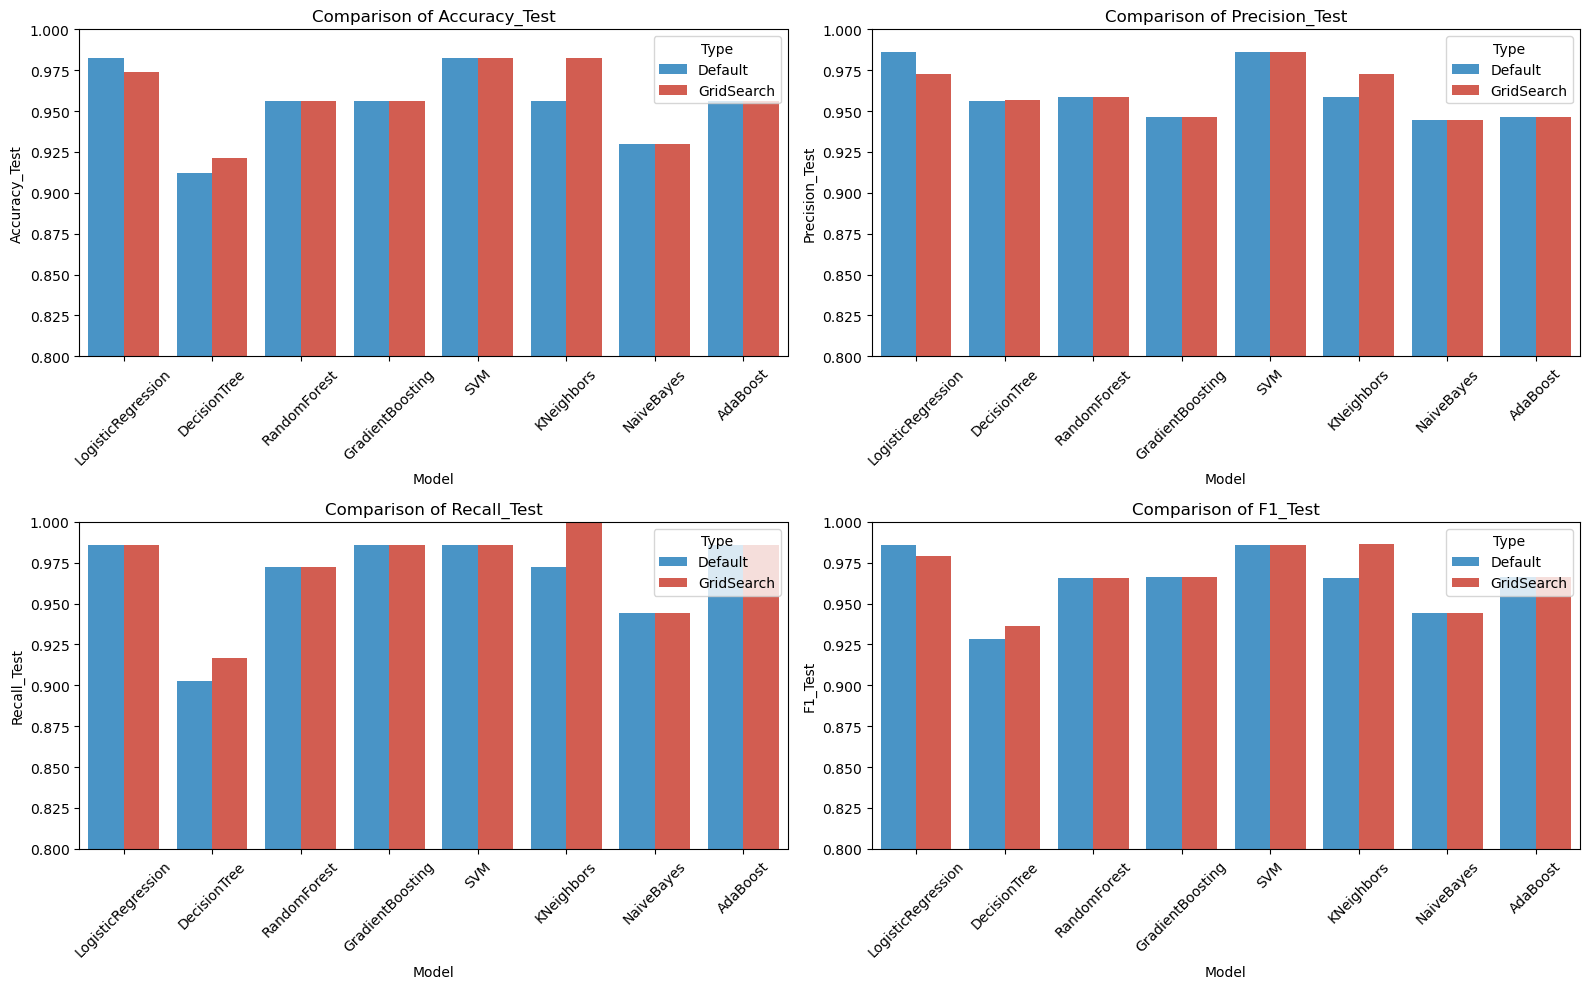

In [62]:
# Prepare data for comparison
results_default_copy = results_default.copy()
results_default_copy['Type'] = 'Default'

results_grid_copy = results_grid.copy()
results_grid_copy['Type'] = 'GridSearch'

combined_df = pd.concat([results_default_copy, results_grid_copy], axis=0)
combined_df.reset_index(inplace=True)

metrics = ['Accuracy_Test', 'Precision_Test', 'Recall_Test', 'F1_Test']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.barplot(data=combined_df, x='Model', y=metric, hue='Type', ax=ax, palette=['#3498db', '#e74c3c'])
    ax.set_title(f'Comparison of {metric}')
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

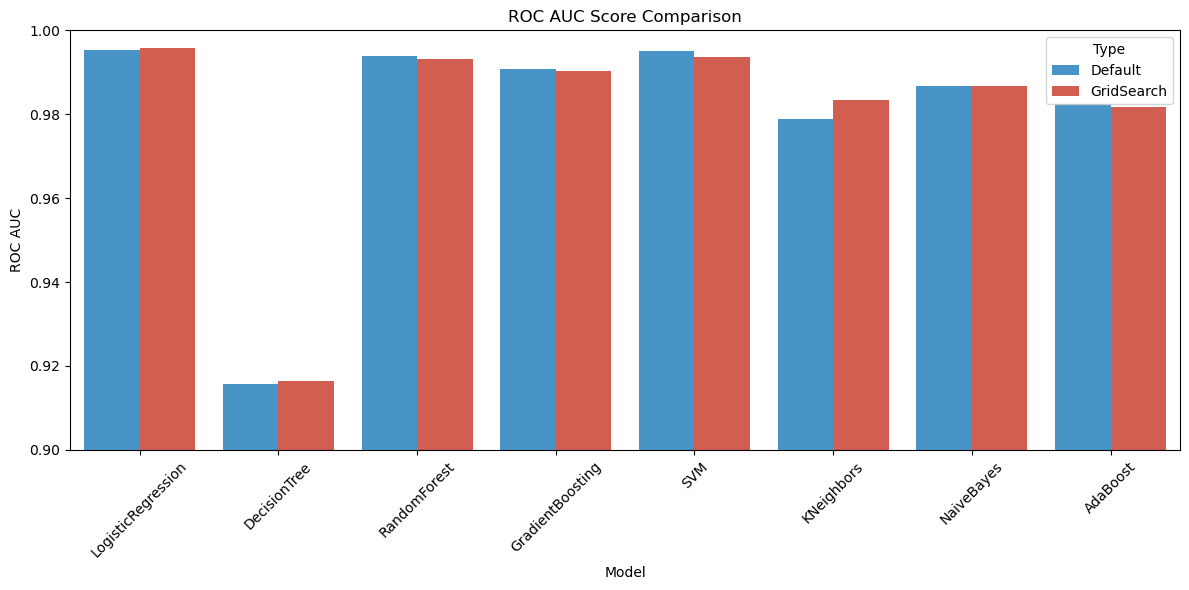

In [63]:
# ROC AUC Comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_df, x='Model', y='ROC_AUC_Test', hue='Type', palette=['#3498db', '#e74c3c'])
plt.title('ROC AUC Score Comparison')
plt.ylabel('ROC AUC')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

## Best Model Analysis

Based on the results, let's analyze the best performing model in detail.

In [64]:
# Find best model based on F1 Test score
best_model_name = results_grid['F1_Test'].idxmax()
best_model = classifier_grid.fitted_models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Best Parameters: {classifier_grid.best_model_params.get(best_model_name, 'Default')}")
print(f"\nTest Metrics:")
print(results_grid.loc[best_model_name])

Best Model: KNeighbors
Best Parameters: {'n_neighbors': 3, 'weights': 'uniform'}

Test Metrics:
Accuracy_Train    0.978022
Accuracy_Test     0.982456
Precision_Test    0.972973
Recall_Test       1.000000
F1_Train          0.982639
F1_Test           0.986301
ROC_AUC_Test      0.983466
Time_s            0.256949
Name: KNeighbors, dtype: float64


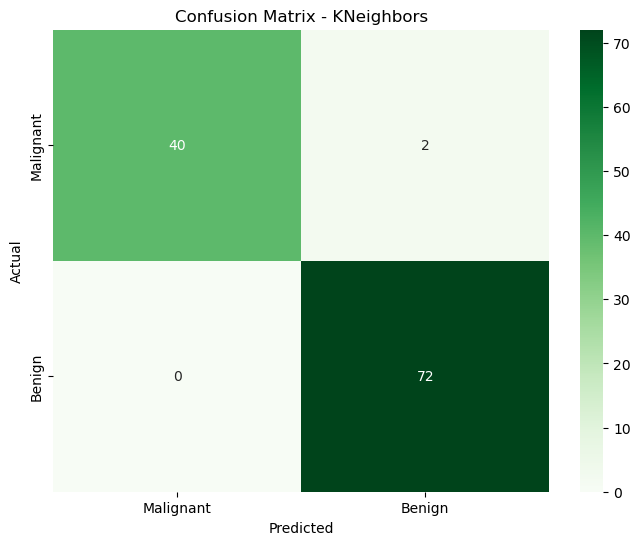


Classification Report - KNeighbors:
              precision    recall  f1-score   support

   Malignant       1.00      0.95      0.98        42
      Benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [65]:
# Confusion Matrix for best model
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Malignant', 'Benign'], 
            yticklabels=['Malignant', 'Benign'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"\nClassification Report - {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['Malignant', 'Benign']))

### ROC Curves

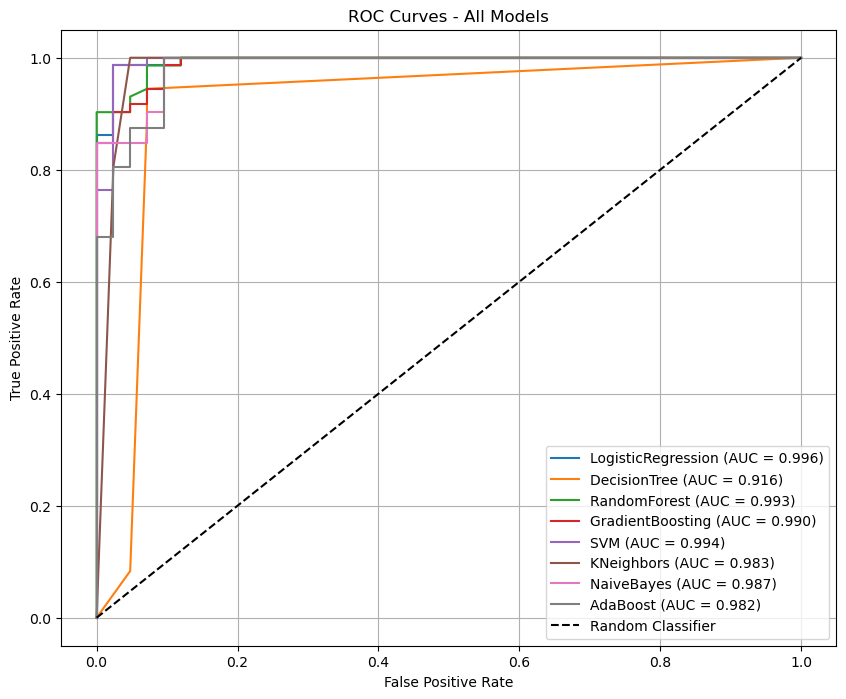

In [66]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in classifier_grid.fitted_models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Feature Importance

C:\Users\susna\AppData\Local\Temp\ipykernel_5712\3276614992.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')


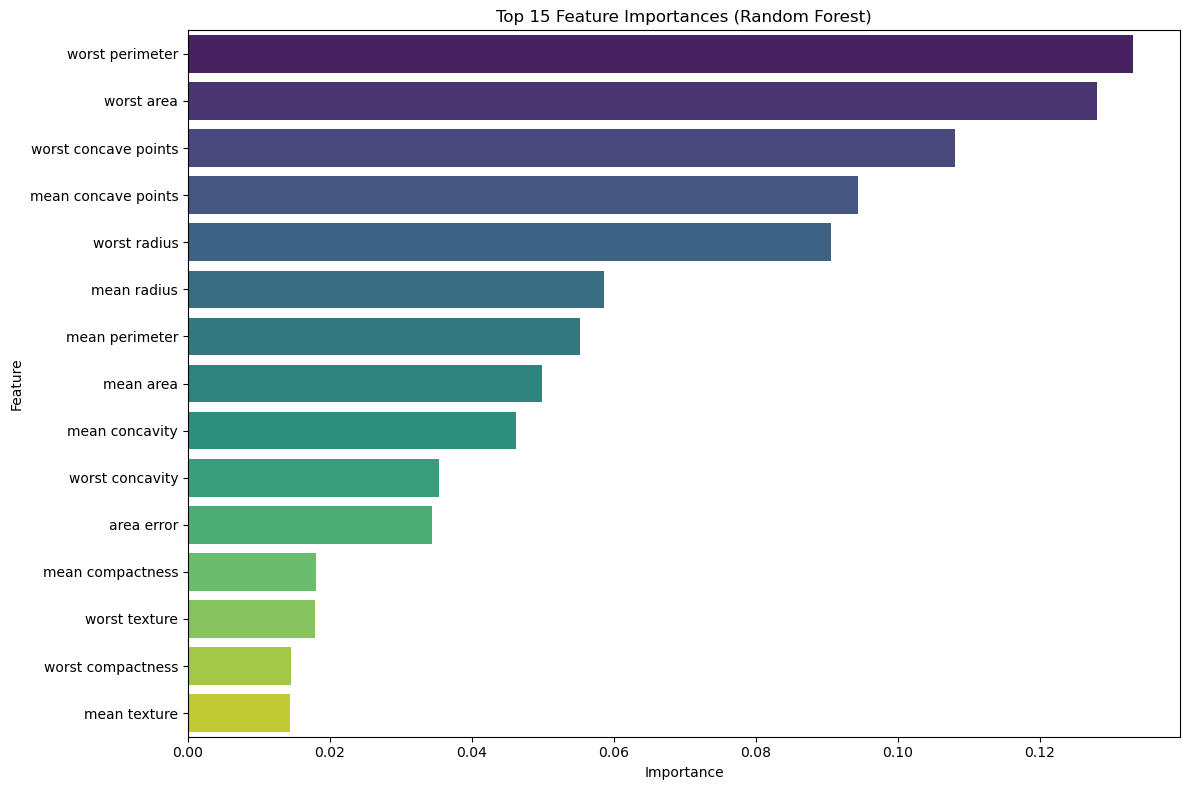

In [67]:
# Feature importance from Random Forest (if available)
if 'RandomForest' in classifier_grid.fitted_models:
    rf_model = classifier_grid.fitted_models['RandomForest']
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
    plt.title('Top 15 Feature Importances (Random Forest)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

## Conclusion

### Key Findings:

1. **Dataset Quality**: The Breast Cancer Wisconsin dataset is clean with no missing values.

2. **Class Balance**: The dataset is slightly imbalanced (62.7% Benign, 37.3% Malignant).

3. **Feature Correlation**: Many features are highly correlated, especially area-related measurements.

4. **Best Features**: Worst concave points, worst perimeter, and worst radius are the most predictive.

5. **Model Performance**: Most models achieve high accuracy (>95%) due to well-separated classes.

### Recommendations:

- For deployment, consider using **Logistic Regression** or **SVM** for interpretability
- **Random Forest** provides good feature importance insights
- In medical applications, **Recall for Malignant class** is crucial (minimize false negatives)

In [68]:
# Final Summary Table
print("=" * 60)
print("FINAL MODEL COMPARISON (GridSearch Results)")
print("=" * 60)
print(results_grid[['Accuracy_Test', 'Precision_Test', 'Recall_Test', 'F1_Test', 'ROC_AUC_Test']].sort_values('F1_Test', ascending=False).to_string())

FINAL MODEL COMPARISON (GridSearch Results)
                    Accuracy_Test  Precision_Test  Recall_Test   F1_Test  ROC_AUC_Test
Model                                                                                 
KNeighbors               0.982456        0.972973     1.000000  0.986301      0.983466
SVM                      0.982456        0.986111     0.986111  0.986111      0.993717
LogisticRegression       0.973684        0.972603     0.986111  0.979310      0.995701
GradientBoosting         0.956140        0.946667     0.986111  0.965986      0.990410
AdaBoost                 0.956140        0.946667     0.986111  0.965986      0.981812
RandomForest             0.956140        0.958904     0.972222  0.965517      0.993221
NaiveBayes               0.929825        0.944444     0.944444  0.944444      0.986772
DecisionTree             0.921053        0.956522     0.916667  0.936170      0.916336
